In [6]:
import pandas as pd
from glob import glob
import numpy as np

pd.set_option("display.max_columns", None) # Show all columns
pd.set_option("display.width", None)        # Use full width of the console
pd.set_option("display.max_colwidth", None)  # Show full content in each column

from PIL import Image
from IPython.display import display

In [ ]:
# This notebook is for
# 1) saving out the preds ran in each set into the aggregated "set__aggregate_allruns" dir.
# 2) summaries/analyses/counts etc

# Note, for preparing dates to run, see /home/csutter/DRIVE-clean/NWS_warnings/notebooks/ncei_dataset_analysis.ipynb. Ultimately using this dataset for events (not the NWS warnings)

In [7]:
# Define the inference set(s) that you want to add to the aggregated dir

aggregate_sets = []

# check that 20220120_2000 in there. and 20220119
# "/home/csutter/DRIVE-clean/operational_runs/set17_summer_examples"
# many missing from squall3 dataset
# need to run a "cleanup run" to catch all the dates across all set dates.csv files that were not ran.. and investigaion as to why? maybe no cam images anywhere for that date? (e.g. xcite down)

# added to aggdir 1/21/26
# ["/home/csutter/DRIVE-clean/operational_runs/set23_squall1",
# "/home/csutter/DRIVE-clean/operational_runs/set24_squall2",
# "/home/csutter/DRIVE-clean/operational_runs/set25_squall3"]

# added to aggdir 11/25/25
# ["/home/csutter/DRIVE-clean/operational_runs/set17_summer_examples",
# "/home/csutter/DRIVE-clean/operational_runs/set18_summer_examples_2",
# "/home/csutter/DRIVE-clean/operational_runs/set19_summer_examples_3",
# "/home/csutter/DRIVE-clean/operational_runs/set20_summer_examples_4",
# "/home/csutter/DRIVE-clean/operational_runs/set21_summer_examples_5",
# "/home/csutter/DRIVE-clean/operational_runs/set22_summer_examples_6"]

# added to aggregate 12/1
# ["/home/csutter/DRIVE-clean/operational_runs/set13_winter22_JFMOnly_041220",
# "/home/csutter/DRIVE-clean/operational_runs/set14_winter2223_NDJFM_041220",
# "/home/csutter/DRIVE-clean/operational_runs/set15_winter2324_NDJFM_041220",
# "/home/csutter/DRIVE-clean/operational_runs/set16_winter2425_NDJFM_041220"]


# 10/8
# ["/home/csutter/DRIVE-clean/operational_runs/set9_winter22_JFMOnly_000816",
# "/home/csutter/DRIVE-clean/operational_runs/set10_winter2223_NDJFM_000816",
# "/home/csutter/DRIVE-clean/operational_runs/set11_winer2324_NDJFM_000816",
# "/home/csutter/DRIVE-clean/operational_runs/set12_winter2425_NDJFM_000816",
# ]



# 9/27 - already added to /home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns
# ["/home/csutter/DRIVE-clean/operational_runs/set1_20250924",
# "/home/csutter/DRIVE-clean/operational_runs/set2_20250924",
# "/home/csutter/DRIVE-clean/operational_runs/set3_20250924",
# "/home/csutter/DRIVE-clean/operational_runs/set4_iceWTA_20250925",
# "/home/csutter/DRIVE-clean/operational_runs/set5_iceWTA_20250925",
# "/home/csutter/DRIVE-clean/operational_runs/set6_probSRsample_20250925",
# "/home/csutter/DRIVE-clean/operational_runs/set7_probSRsample_20250926",
# ]

# First, Save out copies of all final preds in one aggregated directory, across numerous inference set runs; doing this for two reasons:
### Run this code as you run more reference sets -- keep adding to the aggregated dir.


1. Want it all organized for each access for API/dashboard, rather than the API needing to sift through file / dir structures. Although may end up adjusting this stuff. Note that there are two chunks, one for SCM and one for ODM
2. Miscellaneous reasons: small issues in ensembling code - *shouldn't need to run*
    - needed to add select_prob col. That code has since been added to the scripts, so Won't need to run for any sets AFTER set7. But see notes below about this below:
        - For inferenc_run sets 1 through 7, Didnt have the selected cat probability col in the ensemble df - need to add select_prob col
        - But need to have it bc there are a few <1% of cases where the final cat "select" col does not align with ensembleavg method. Thus cant just rely on ensembleAvg_predprob
        - But at the time of many of the inference run sets, did not have that code in /home/csutter/DRIVE-clean/operational_inference/inference_ensemble.py and /home/csutter/DRIVE-clean/ensembling/scripts/nested_ensemble.py
        - As ad hoc fix, read in all the inference runs and 
    - low confidence should have been <=1.5 not <1, bc the min is 1, and that forced even the lowest confidence into medium. Fix this! See inference_ensemble.py for more info and https://docs.google.com/spreadsheets/d/1cnNLpkQ-XFYmPvYEwAh67HFW1mgloYDjSHmKpe0wV08/edit?gid=0#gid=0


#### SCM

In [8]:
### SCM -- collect file and date info

scm_finalpreds = []

for set in aggregate_sets:
    filepath = glob(f"{set}/data_6_ensembling/*/*/*/*/*")
    # print(len(filepath))
    # print(filepath)
    # find datetime
    for f in filepath:
        # print(f)
        scm_finalpreds.append(f)
    print(set)
    print(len(filepath))

print("instances for which we have predictions")
print(len(scm_finalpreds))
scm_finalpreds[0]

/home/csutter/DRIVE-clean/operational_runs/set23_squall1
290
/home/csutter/DRIVE-clean/operational_runs/set24_squall2
301
/home/csutter/DRIVE-clean/operational_runs/set25_squall3
92
instances for which we have predictions
683


'/home/csutter/DRIVE-clean/operational_runs/set23_squall1/data_6_ensembling/2022/12/23/20221223_1420/finalpreds.csv'

In [5]:
# # check that images has same amount? Problem solving 1/21/26 for why not full list of dates being ran in the inference code... come back to 

# scm_finalpreds = []

# for set in aggregate_sets:
#     filepath = glob(f"{set}/data_1_images/*/*/*/*/*")
#     # print(len(filepath))
#     # print(filepath)
#     # find datetime
#     for f in filepath:
#         # print(f)
#         scm_finalpreds.append(f)
#     print(set)
#     print(len(filepath))

# print("instances for which we have predictions")
# print(len(scm_finalpreds))
# scm_finalpreds[0]

/home/csutter/DRIVE-clean/operational_runs/set23_squall1
290
/home/csutter/DRIVE-clean/operational_runs/set24_squall2
301
/home/csutter/DRIVE-clean/operational_runs/set25_squall3
93
instances for which we have predictions
684


'/home/csutter/DRIVE-clean/operational_runs/set23_squall1/data_1_images/2022/12/23/20221223_1420/step1_imgfiles.csv'

In [9]:
### CODE A: Save out copies to aggregated dir

for f in scm_finalpreds:
    try:
        d = pd.read_csv(f)
    except:
        print("issue opening")
        print(f)
    # save this out in aggregated dir
    # print(f)
    beg = f.rfind("data_6")
    dirstruct = f[beg:]
    # print(dirstruct)
    saveto = f"/home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns/{dirstruct}"
    # print(os.path.dirname(saveto))
    os.makedirs(os.path.dirname(saveto), exist_ok = True)
    # print(saveto)
    d.to_csv(saveto)

# note: took 5 min to run 950 dfs

In [20]:
### OPT B: to run if need to fix issues (adhoc/misc). Really should not need to do this unless updating ensembling rules, for example. 
# CAUTION! Only run if need to fix things. If Only need to save out copies into aggregate dir, run OPT B

### Fix confidence issue (see note above)
def confidence_qual(row):
    overall = row["conf_overall"]
    if overall <= 1.5: 
        conf = "low"
    elif overall == 2:
        conf = "medium"
    elif overall >= 2.5: 
        conf = "high"
    else:
        conf = "issue_confidence"
    return conf

### Add select_prob (see note above)
def selectprob(row): # note that this is in nested_ensemble as of 9/26, so will be autoomatically applied after set 7
    pred = row["select"]
    grabprob = row[f"ensembleAvg_{pred}"]
    return grabprob

#### RUN these new functions and save out into new organized dir! Dont want to lose original work though in case something goes awry with this. 

for f in scm_finalpreds:
    d = pd.read_csv(f)
    d["select_prob"] =  d.apply(selectprob, axis=1)
    d["confidence"] = d.apply(confidence_qual, axis = 1)
    # save this out in aggregated dir
    beg = f.rfind("data_6")
    dirstruct = f[beg:]
    saveto = f"/home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns/{dirstruct}"
    # print(os.path.dirname(saveto))
    os.makedirs(os.path.dirname(saveto), exist_ok = True)
    # print(saveto)
    d.to_csv(saveto)

# note: took 5.5 min to run 1100 instances

### ODM

In [10]:
# ODM

odm_finalpreds = []
odm_datetime = []

for set in aggregate_sets:
    filepath = glob(f"{set}/data_odm_3_ensembling/*/*/*/*/*")
    # print(len(filepath))
    # print(filepath)
    # find datetime
    for f in filepath:
        i = f.rfind("/")
        filedate = f[i-13:i]
        odm_finalpreds.append(f)
        odm_datetime.append(filedate)
    print(set)
    print(len(filepath))

print("instances for which we have predictions")
print(len(odm_finalpreds))

/home/csutter/DRIVE-clean/operational_runs/set23_squall1
289
/home/csutter/DRIVE-clean/operational_runs/set24_squall2
301
/home/csutter/DRIVE-clean/operational_runs/set25_squall3
92
instances for which we have predictions
682


In [11]:
### CODE A: Save out copies to aggregated dir
# Generally the same code as above for SCM
for f in odm_finalpreds:
    d = pd.read_csv(f)
    # save this out in aggregated dir
    beg = f.rfind("data_odm_3")
    dirstruct = f[beg:]
    saveto = f"/home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns/{dirstruct}"
    # print(os.path.dirname(saveto))
    os.makedirs(os.path.dirname(saveto), exist_ok = True)
    # print(saveto)
    d.to_csv(saveto)

# note: Runs faster than the SCM code

In [23]:
saveto

'/home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns/odm_3_ensembling/2024/11/14/20241114_1200/finalpreds.csv'

In [19]:
# Save out ODM in aggregated dir
# Generally the same as code above for SCM

### OPT B: to run if need to fix issues (adhoc/misc)
# CAUTION! Only run if need to fix things. If Only need to save out copies into aggregate dir, run OPT B

### Fix confidence issue (see note above)
def confidence_qual(row):
    overall = row["conf_overall"]
    if overall <= 1.5: 
        conf = "low"
    elif overall == 2:
        conf = "medium"
    elif overall >= 2.5: 
        conf = "high"
    else:
        conf = "issue_confidence"
    return conf

### Add select_prob (see note above)
def selectprob(row): # note that this is in nested_ensemble as of 9/26, so will be autoomatically applied after set 7
    pred = row["select"]
    grabprob = row[f"ensembleAvg_{pred}"]
    return grabprob

#### RUN these new functions and save out into new organized dir! Dont want to lose original work though in case something goes awry with this. 

for f in odm_finalpreds:
    d = pd.read_csv(f)
    d["select_prob"] =  d.apply(selectprob, axis=1)
    d["confidence"] = d.apply(confidence_qual, axis = 1)
    # save this out in aggregated dir
    beg = f.rfind("data_odm_3")
    dirstruct = f[beg:]
    saveto = f"/home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns/{dirstruct}"
    # print(os.path.dirname(saveto))
    os.makedirs(os.path.dirname(saveto), exist_ok = True)
    # print(saveto)
    d.to_csv(saveto)

# note: took 2.5 min to run ~1100 dfs

# Summaries using the aggregated dir
- To get high level summaries, e.g., identifying dates with many severe snow

In [ ]:
# For summaries, need to grab files from newly organized aggregated
scm_finalpreds = []
scm_datetime = []

filepath_scm = glob(f"/home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns/data_6_ensembling/*/*/*/*/*")
# print(len(filepath))
# print(filepath)
# find datetime
for f in filepath_scm:
    i = f.rfind("/")
    filedate = f[i-13:i]
    scm_finalpreds.append(f)
    scm_datetime.append(filedate)

# Grab files from newly organized aggregated
odm_finalpreds = []
odm_datetime = []

filepath_odm = glob(f"/home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns/data_odm_3_ensembling/*/*/*/*/*")
# print(len(filepath))
# print(filepath)
# find datetime
for f in filepath_odm:
    i = f.rfind("/")
    filedate = f[i-13:i]
    odm_finalpreds.append(f)
    odm_datetime.append(filedate)


# Print totals -- for counting what instances we have, simple count
print(len(scm_finalpreds))
print(len(scm_datetime))
print(len(np.unique(scm_datetime))) # if this is less than the full len, it just means some of the datetimes were ran in multiple sets. Not a big deal, just duplicate ran more than once

# jsut to grab the total of unique DATES ran
scm_dates = [i[0:8] for i in scm_datetime]
print("unique dates ran")
print(len(np.unique(scm_dates)))

# print some examples to see
print("examples")
print(scm_finalpreds[0:3])
print(scm_datetime[0:3])
print(scm_dates[0:3])


# Print totals -- for counting what instances we have, simple count
print(len(odm_finalpreds))
print(len(odm_datetime))
print(len(np.unique(odm_datetime))) # if this is less than the full len, it just means some of the datetimes were ran in multiple sets. Not a big deal, just duplicate ran more than once

# jsut to grab the total of unique DATES ran
odm_dates = [i[0:8] for i in odm_datetime]
print("unique dates ran")
print(len(np.unique(odm_dates)))

# print some examples to see
print("examples")
print(odm_finalpreds[0:3])
print(odm_datetime[0:3])
print(odm_dates[0:3])


### Make summary: of counts across classes for each instance, highest level summary

In [ ]:
# Organize SCM and ODM together

scm_catlist = ["dry", "poor_viz","snow","snow_severe","wet"]
scm_filelist = []
scm_catcount = [] # each list entry has order of dry, poor_viz, etc

odm_catlist = ["nonobs","obs"]
odm_filelist = []
odm_catcount = [] # each list entry has order of dry, poor_viz, etc

dateinstance = []
ymd = []

def count_cat(dfinput, catinput):
    df2 = dfinput[dfinput["select"]==catinput]
    return len(df2)

for i in range(0,len(scm_finalpreds)): #len(scm_finalpreds)
    # grab corresponding date st we can find it in ODM list
    dt = scm_datetime[i]
    dateonly = scm_dates[i]
    try: # this way if the time doesnt exist in ODM, we can skip this instance
        odm_index = odm_datetime.index(dt)
    except:
        continue # this continue immediately stops the code from running more below, and moves on to next iteration in loop. Key thing with continue is that it doesn't run the rest of the code below. Benefit of this is that it isolates the "try" command. For example if we lumped ALL code under try (and therefore wouldn need the continue line), we wouldnt be able to isolate for what reason the try didn't work. Since now it's only trying to find the odm index, we know exactly what try failed. 

    # grab file names for SCM and ODM, will have both (see the try/except above)
    scmfile = scm_finalpreds[i]
    odmfile = odm_finalpreds[odm_index]

    scmdf = pd.read_csv(scmfile)
    odmdf = pd.read_csv(odmfile)
    # display(odmdf)
    # grab scm cat counts and append
    scm_catcount_instance = []
    for cat in scm_catlist:
        ct = count_cat(scmdf, cat)
        scm_catcount_instance.append(ct)
    scm_filelist.append(scmfile)
    scm_catcount.append(scm_catcount_instance) # append list from instance to outer list

    # grab odm cat counts and append
    odm_catcount_instance = []
    for cat in odm_catlist:
        ct = count_cat(odmdf, cat)
        odm_catcount_instance.append(ct)
    odm_filelist.append(odmfile)
    odm_catcount.append(odm_catcount_instance) # append list from instance to outer list

    dateinstance.append(dt) # put at  end bc want the code to have ran before adding this date as successul for tracking
    ymd.append(dateonly)


# print(scm_filelist)
# print(scm_catcount)
# print(odm_filelist)
# print(odm_catcount)
# print(dateinstance)


df_countall_scm = pd.DataFrame(scm_catcount, columns=scm_catlist)
df_countall_scm["scm_run"] = scm_filelist

df_countall_odm = pd.DataFrame(odm_catcount, columns=odm_catlist)
df_countall_odm["odm_run"] = odm_filelist

print(len(df_countall_scm),len(df_countall_odm))

df_all = pd.concat([df_countall_scm,df_countall_odm], axis = 1) # concat cols side by side
print(len(df_all))

df_all["datetime"] = dateinstance
df_all["date"] = ymd

display(df_all.head(4))

# takes 1-2 mins


### From that summary ^ identify dates with most severe snow examples

In [ ]:
sort_sevsnow = df_all.sort_values(["snow_severe"], ascending = False)
sort_sevsnow

In [ ]:
list(sort_sevsnow["datetime"][0:10])

# Specific case-study analysis
- Marry the two model dfs at the prediction-level, to get paired prediction of 5cat|ynobs
- For now dont necessarily need to do this for every inference instance, although may want to bc that will be related to the API work getting that all prepped in one spot for dashboard. Will need to come back to this
- For now, use the df of severe snow identification dates above to do case studies/investigate certain dates

### Case study

In [31]:
# for top_datetime in list(sort_sevsnow["datetime"]):

# identifying model paths Way 1, requires that we ran the code chunk above and have a subset df from which we're looking, which is the method that may be useful when needing to first identify subset of dates with high snow
# datetime_ofint = "20220129_1300"
# scm = sort_sevsnow[sort_sevsnow["datetime"]==datetime_ofint]["scm_run"].item()
# odm = sort_sevsnow[sort_sevsnow["datetime"]==datetime_ofint]["odm_run"].item()

# identifying model paths Way 2
# if we know exactly which instance we want to look at. Quicker, relevant only if we already have a date in mind.

# Example been using for slides
# scm = "/home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns/data_6_ensembling/2022/01/29/20220129_1300/finalpreds.csv"
# odm = "/home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns/data_odm_3_ensembling/2022/01/29/20220129_1300/finalpreds.csv"


scm = "/home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns/data_6_ensembling/2024/01/15/20240115_1200/finalpreds.csv"

odm = "/home/csutter/DRIVE-clean/operational_runs/set__aggregate_allruns/data_odm_3_ensembling/2024/01/15/20240115_1200/finalpreds.csv"


s = pd.read_csv(scm)
s = s[['img_orig', 'site', 'img_name','Latitude', 'Longitude','timeofday','select','select_prob','confidence']]
o = pd.read_csv(odm)
o = o[['img_orig','select','select_prob','confidence']]
print(s.columns)
print(o.columns)

cols_torename = ['select','select_prob','confidence'] # model specific preds
cols_rename_scm = [f"{x}_scm" for x in cols_torename] # for scm keep all the identifier cols (wont carry them over for odm)
cols_rename_odm = [f"{x}_odm" for x in cols_torename]
rename_scm = dict(zip(cols_torename,cols_rename_scm))
rename_odm = dict(zip(cols_torename,cols_rename_odm))
s = s.rename(columns = rename_scm)
o = o.rename(columns = rename_odm)
print(s.columns)
print(o.columns)


df = s.merge(o, how = "inner", on = "img_orig")

df[800:810]

Index(['img_orig', 'site', 'img_name', 'Latitude', 'Longitude', 'timeofday',
       'select', 'select_prob', 'confidence'],
      dtype='object')
Index(['img_orig', 'select', 'select_prob', 'confidence'], dtype='object')
Index(['img_orig', 'site', 'img_name', 'Latitude', 'Longitude', 'timeofday',
       'select_scm', 'select_prob_scm', 'confidence_scm'],
      dtype='object')
Index(['img_orig', 'select_odm', 'select_prob_odm', 'confidence_odm'], dtype='object')


,img_orig,site,img_name,Latitude,Longitude,timeofday,select_scm,select_prob_scm,confidence_scm,select_odm,select_prob_odm,confidence_odm
800,"/home/csutter/cron/data/TRAFFICLAND_13006/20240115/I_80_EB_@_NJ_17_Southbound,_Lodi__Northbound__TRAFFICLAND_13006_2024-01-15-12:00:52.jpg",TRAFFICLAND_13006,"I_80_EB_@_NJ_17_Southbound,_Lodi__Northbound__TRAFFICLAND_13006_2024-01-15-12:00:52.jpg",40.886014,-74.068977,dawn,dry,0.704533,high,obs,0.941434,high
801,"/home/csutter/cron/data/TRAFFICLAND_13005/20240115/I_80_WB_@_NJ_17_Northbound,_Lodi__Northbound__TRAFFICLAND_13005_2024-01-15-12:00:52.jpg",TRAFFICLAND_13005,"I_80_WB_@_NJ_17_Northbound,_Lodi__Northbound__TRAFFICLAND_13005_2024-01-15-12:00:52.jpg",40.884403,-74.066567,dawn,dry,0.704533,high,obs,0.941434,high
802,"/home/csutter/cron/data/TRAFFICLAND_6433/20240115/I_80_w_o__Garden_State_Parkway,_Elmwood_Park__Westbound__TRAFFICLAND_6433_2024-01-15-12:00:24.jpg",TRAFFICLAND_6433,"I_80_w_o__Garden_State_Parkway,_Elmwood_Park__Westbound__TRAFFICLAND_6433_2024-01-15-12:00:24.jpg",40.904277,-74.108587,dawn,dry,0.728580,high,obs,0.941434,high
803,/home/csutter/cron/data/Skyline_6245/20240115/I_81_at_Count_Station_(Whitney_Point)__Southbound__Skyline_6245_2024-01-15-12:00:33.jpg,Skyline_6245,I_81_at_Count_Station_(Whitney_Point)__Southbound__Skyline_6245_2024-01-15-12:00:33.jpg,42.305223,-75.941866,dawn,dry,0.800041,high,nonobs,1.000000,high
804,/home/csutter/cron/data/Skyline_5681/20240115/I_81_at_Exit_4__Southbound__Skyline_5681_2024-01-15-12:00:26.jpg,Skyline_5681,I_81_at_Exit_4__Southbound__Skyline_5681_2024-01-15-12:00:26.jpg,42.114490,-75.898790,dawn,dry,0.566010,high,nonobs,1.000000,high
805,/home/csutter/cron/data/Skyline_6163/20240115/I_81_at_Exit_50__Northbound__Skyline_6163_2024-01-15-12:00:32.jpg,Skyline_6163,I_81_at_Exit_50__Northbound__Skyline_6163_2024-01-15-12:00:32.jpg,44.289664,-75.970898,night,snow,0.313611,low,obs,0.941434,high
806,/home/csutter/cron/data/Skyline_5680/20240115/I_81_at_Exit_5__Northbound__Skyline_5680_2024-01-15-12:00:24.jpg,Skyline_5680,I_81_at_Exit_5__Northbound__Skyline_5680_2024-01-15-12:00:24.jpg,42.123578,-75.905098,dawn,dry,0.614477,medium,nonobs,1.000000,high
807,/home/csutter/cron/data/Skyline_6162/20240115/I_81_at_NY_178_(Exit_41)__Northbound__Skyline_6162_2024-01-15-12:00:32.jpg,Skyline_6162,I_81_at_NY_178_(Exit_41)__Northbound__Skyline_6162_2024-01-15-12:00:32.jpg,43.811311,-76.034626,night,snow_severe,0.645675,high,nonobs,0.581541,medium
808,/home/csutter/cron/data/Skyline_6174/20240115/I_81_at_NY_PA_Border_Truck_Inspection_Station__Northbound__Skyline_6174_2024-01-15-12:00:30.jpg,Skyline_6174,I_81_at_NY_PA_Border_Truck_Inspection_Station__Northbound__Skyline_6174_2024-01-15-12:00:30.jpg,42.002005,-75.752725,dawn,dry,0.631473,high,nonobs,0.989362,high
809,/home/csutter/cron/data/Skyline_6246/20240115/I_81_at_RWIS_(Killawog)__Southbound__Skyline_6246_2024-01-15-12:00:35.jpg,Skyline_6246,I_81_at_RWIS_(Killawog)__Southbound__Skyline_6246_2024-01-15-12:00:35.jpg,42.400195,-76.009697,dawn,dry,0.603336,high,nonobs,1.000000,high


For case study - find image examples

- Spot checking images some examples
- Not rigorous like analysis across a labeled test set, but just spot checking some inference
- See https://docs.google.com/presentation/d/1gvuW99Kq-99CwemfyfPQoKe_6jP0dAq2Y33i6Kv1nwQ/edit?slide=id.g36661c25ec1_0_61#slide=id.g36661c25ec1_0_61

In [ ]:
df[df["confidence_odm"]=="high"]

In [ ]:
df[((df["confidence_odm"]=="high") & (df["select_odm"]=="obs"))][0:5]

try to find wrong high conf obs


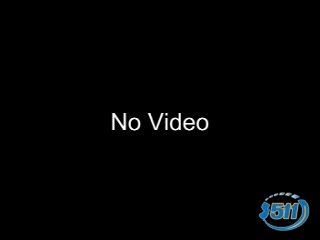

In [19]:
print("try to find wrong high conf obs")
img = Image.open('/home/csutter/cron/data/TRAFFICLAND_65203/20220129/I_280_@_Laurel_Ave__Eastbound__TRAFFICLAND_65203_2022-01-29-12:57:41.jpg')
display(img)


In [ ]:
# low wet, medium nonobs

img = Image.open('/home/csutter/cron/data/Skyline_5042/20220129/West_Main_St_at_South_Plymouth_Ave__Unknown__Skyline_5042_2022-01-29-13:00:43.jpg')
display(img)

In [ ]:
# high sev snow, medium obs
img = Image.open('/home/csutter/cron/data/Skyline_2234/20220129/WSP_Exits_W04_W05_at_Park_Ave__Southbound__Skyline_2234_2022-01-29-13:00:25.jpg')
display(img)


In [ ]:
# Medium confidence scm sev snow, high confidence obs --> is obs
print("here 6")
img = Image.open('/home/csutter/cron/data/Skyline_2322/20220129/907M_at_Roosevelt_Avenue__Eastbound__Skyline_2322_2022-01-29-13:00:02.jpg')
display(img)

In [ ]:


# High confidence scm sev snow, high confidence obs --> is obs
img = Image.open('/home/csutter/cron/data/TRAFFICLAND_6427/20220129/001_9T_(MM_002.00)_WB_E_of_Hackey_Brdg__Westbound__TRAFFICLAND_6427_2022-01-29-13:01:11.jpg')
display(img)

# High confidence scm sev snow, high confidence obs --> is obs
img = Image.open('/home/csutter/cron/data/Skyline_6460/20220129/I_287_Just_East_of_Interchange_9_(Hutchinson_River_Parkway)__Westbound__Skyline_6460_2022-01-29-13:00:19.jpg')
display(img)

# High confidence scm sev snow, medium confidence nonobs 
img = Image.open('/home/csutter/cron/data/Skyline_8340/20220129/I_87_at_234_st__Southbound__Skyline_8340_2022-01-29-13:00:29.jpg')
display(img)

# High confidence scm snow, high conf nonobs
img = Image.open('/home/csutter/cron/data/Skyline_8338/20220129/I_678_at_7_ave__Northbound__Skyline_8338_2022-01-29-13:00:28.jpg')
display(img)

# high conf snow, low conf nonobs
# GREAT ONE!! Just takes up so much room. comment out
# print("here2")
# img = Image.open('/home/csutter/cron/data/NYSDOT_omhzfbr0rt5/20220129/Bronx_River_Pkwy_NB_&_Harney_Rd_&_Strathmore_Rd__Northbound__NYSDOT_omhzfbr0rt5_2022-01-29-13:00:16.jpg')
# display(img)



# Medium SCM severe snow, low confidence nonobs
img = Image.open("/home/csutter/cron/data/Skyline_6398/20220129/I_287_CWE_at_I_87_Interchange_8__Westbound__Skyline_6398_2022-01-29-13:00:16.jpg")
display(img)

# medium snow, med nonobs
print("here 4 5")
img = Image.open("/home/csutter/cron/data/Skyline_2320/20220129/907M_at_27th_Avenue__Westbound__Skyline_2320_2022-01-29-13:00:25.jpg")
display(img)

# medium snow, med obs
img = Image.open("/home/csutter/cron/data/NYSDOT_4616395/20220129/12_Avenue_@_22_Street__Both_Directions__NYSDOT_4616395_2022-01-29-12:57:32.jpg")
display(img)

# medium snow low obs
print("here3")
img = Image.open("/home/csutter/cron/data/Skyline_5578/20220129/I_787,_US_9_US_20,_South_Mall_Expressway_from_east_side_of_the_Corning_Tower__Eastbound__Skyline_5578_2022-01-29-13:02:09.jpg")
display(img)

# low confidence SCM prediction - "snow" (wrong)
img = Image.open('/home/csutter/cron/data/TRAFFICLAND_6434/20220129/001_9T_(MM_003.10)_WB_at_Sip_Ave__Westbound__TRAFFICLAND_6434_2022-01-29-13:01:37.jpg')
display(img)

# low confidence sev snow scm, high confidence nonobs
img = Image.open("/home/csutter/cron/data/Skyline_8253/20220129/907M_at_W_B_I_278_BQE_Ramp__Westbound__Skyline_8253_2022-01-29-13:00:27.jpg")
display(img)

# low confidence wet scm, high confidence nonobs
img = Image.open("/home/csutter/cron/data/Skyline_2087/20220129/I_87_at_Exit_13_(US_9,_Saratoga_Springs)__Northbound__Skyline_2087_2022-01-29-13:02:07.jpg")
display(img)


# low pv, low nonobs
img = Image.open("/home/csutter/cron/data/Skyline_6319/20220129/Route_5_Eastbound_at_Lake_Erie_Blvd__Eastbound__Skyline_6319_2022-01-29-13:00:12.jpg")
display(img)


Could use tesseract text reading tool to verify skill of obs, too, and then manually check just the obs that arent as text written

In [ ]:
# come back to this

For case study -- Confidence level bin count - cont the amount in each of the High, Med, Low conf grid
- see https://docs.google.com/presentation/d/1gvuW99Kq-99CwemfyfPQoKe_6jP0dAq2Y33i6Kv1nwQ/edit?slide=id.g36661c25ec1_0_61#slide=id.g36661c25ec1_0_61 for more detail

In [9]:
df_confbuckets = df[["confidence_odm","select_odm","confidence_scm","img_orig"]].groupby(["confidence_odm","select_odm","confidence_scm"]).count().reset_index()

df_confbuckets

,confidence_odm,select_odm,confidence_scm,img_orig
0,high,nonobs,high,848
1,high,nonobs,low,464
2,high,nonobs,medium,331
3,high,obs,high,363
4,high,obs,low,109
5,high,obs,medium,97
6,low,nonobs,high,16
7,low,nonobs,low,9
8,low,nonobs,medium,7
9,low,obs,high,4


In [ ]:
# what makes sense is if the high confidence obs have mostly low/med confidence SCM
# assess this by seeing the percentage (paste in excel)

In [22]:
df_confbuckets = df[["confidence_odm","select_odm","confidence_scm","img_orig"]].groupby(["confidence_odm","select_odm","confidence_scm"]).count().reset_index()

df_confbuckets

,confidence_odm,select_odm,confidence_scm,img_orig
0,high,nonobs,high,841
1,high,nonobs,low,451
2,high,nonobs,medium,327
3,high,obs,high,360
4,high,obs,low,111
5,high,obs,medium,101
6,low,nonobs,high,14
7,low,nonobs,low,7
8,low,nonobs,medium,4
9,low,obs,high,14


In [33]:
df_confbuckets = df[["confidence_odm","confidence_scm","img_orig"]].groupby(["confidence_scm","confidence_odm"]).count().reset_index()

df_confbuckets

,confidence_scm,confidence_odm,img_orig
0,high,high,1822
1,high,low,6
2,high,medium,38
3,low,high,250
4,low,low,8
5,low,medium,19
6,medium,high,212
7,medium,low,3
8,medium,medium,8


In [32]:
df_confbuckets = df[["confidence_odm","confidence_scm","img_orig"]].groupby(["confidence_odm","confidence_scm"]).count().reset_index()

df_confbuckets

,confidence_odm,confidence_scm,img_orig
0,high,high,1822
1,high,low,250
2,high,medium,212
3,low,high,6
4,low,low,8
5,low,medium,3
6,medium,high,38
7,medium,low,19
8,medium,medium,8


Show storm moving across state?
